---
tags: [algorithm, sample-based]
---

# Quantum-enhanced Markov chain Monte Carlo (QeMCMC)

This tutorial demonstrates how to implement Quantum-enhanced Markov chain
Monte Carlo (QeMCMC) {cite:p}`10.1038/s41586-023-06095-4` using
Qamomile.

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[qiskit]"

In [2]:
import os
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer import AerSimulator

import qamomile.circuit as qmc
from qamomile.circuit.algorithm import trotterized_time_evolution
from qamomile.circuit.stdlib import computational_basis_state
from qamomile.observable.hamiltonian import Hamiltonian, X, Z
from qamomile.qiskit import QiskitTranspiler

---
## Background

### Sampling the Boltzmann Distribution

In many physics and engineering problems, drawing samples $\bm{x}$ from a
probability distribution $\mu(\bm{x})$ is a central computational task.
A classic example is the **Boltzmann distribution** from statistical
mechanics:
$$
\mu(\bm{x}) = \frac{1}{Z} \exp\bigl(-\beta E(\bm{x})\bigr), \quad Z = \sum_{\bm{x}} \exp\bigl(-\beta E(\bm{x})\bigr).
$$
Here, $E(\bm{x})$ is the energy of state $\bm{x}$, $\beta = 1/T$ is the
inverse temperature, and $Z$ is the normalization constant known as the
partition function.
Beyond giving the probability distribution of state $\bm{x}$ at thermal
equilibrium, sampling that targets the Boltzmann distribution is also
widely used as an approach for combinatorial optimization problems.

As a concrete example of an energy function for the Boltzmann distribution,
consider the **Ising model**.
The Ising model is a system with a spin variable $x_i \in \{-1, +1\}$ at
each site $i$, whose energy is given by:
$$
E(\bm{x}) = -\sum_{\langle i, j \rangle} J_{ij} \, x_i x_j - \sum_i h_i \, x_i.
$$
Here, $J_{ij}$ is the interaction between spins and $h_i$ is the external
magnetic field at site $i$.
Since the total number of states grows exponentially as $2^n$, computing
the partition function $Z$ exactly becomes intractable for large $n$.
MCMC, introduced below, is therefore used to draw samples directly from
$\mu(\bm{x})$.

First, let us actually visualize the Boltzmann distribution for a small
Ising model.
We take a 1D ferromagnetic Ising chain ($J_{i,i+1} = 1$, $h_i = 0$) and plot
histograms of the probability aggregated by energy $E(\bm{x})$ for several
values of the inverse temperature $\beta$.

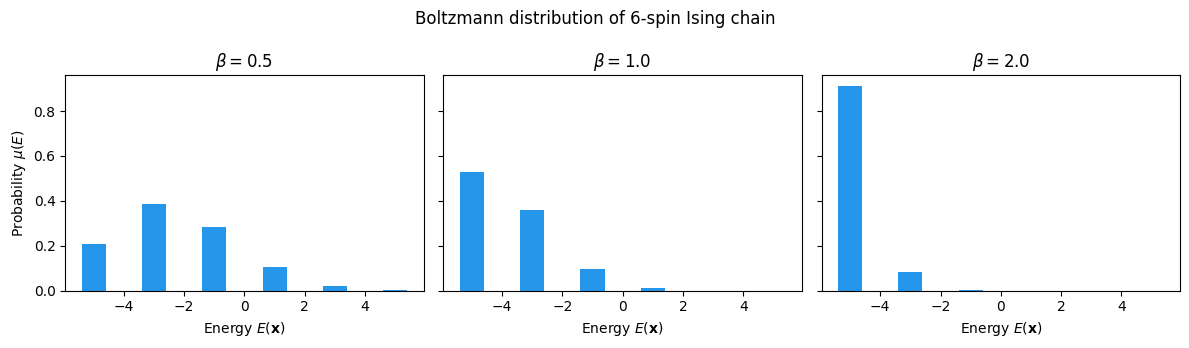

In [3]:
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
RANDOM_SEED = 42
QAOA_BLUE = "#2696EB"
QAOA_RED = "#FF6B6B"

n_spins = 6
J = 1.0


def ising_energy(state: np.ndarray) -> float:
    """Return the energy of a 1D ferromagnetic Ising chain (no external field)
    for the spin configuration ``state``."""
    return -J * np.sum(state[:-1] * state[1:])


# Enumerate all 2^n states
all_states = np.array(
    [[1 - 2 * ((k >> i) & 1) for i in range(n_spins)] for k in range(2**n_spins)]
)
energies = np.array([ising_energy(s) for s in all_states])
# All 2^n spin configurations on n_spins sites, with energies bounded by
# the ferromagnetic / antiferromagnetic extrema +/- (n - 1) * J.
assert all_states.shape == (2**n_spins, n_spins)
assert energies.shape == (2**n_spins,)
assert energies.min() == -(n_spins - 1) * J
assert energies.max() == (n_spins - 1) * J

# Aggregate the Boltzmann distribution by energy and plot as a histogram
unique_energies = np.unique(energies)
betas = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(betas), figsize=(12, 3.5), sharey=True)
for ax, beta in zip(axes, betas):
    weights = np.exp(-beta * energies)
    probs = weights / weights.sum()
    e_probs = np.array([probs[energies == e].sum() for e in unique_energies])
    ax.bar(unique_energies, e_probs, width=0.8, color=QAOA_BLUE)
    ax.set_xlabel(r"Energy $E(\mathbf{x})$")
    ax.set_title(rf"$\beta = {beta}$")
axes[0].set_ylabel(r"Probability $\mu(E)$")
fig.suptitle(f"Boltzmann distribution of {n_spins}-spin Ising chain")
plt.tight_layout()
plt.show()

### Markov chain Monte Carlo (MCMC)

Markov chain Monte Carlo (MCMC) is a general-purpose method for sampling
from probability distributions.
It achieves sampling from a target distribution $\mu(\bm{x})$ by exploiting
a stochastic process called a Markov chain.
Here we introduce the Metropolis-Hastings (MH) algorithm
{cite:p}`10.1093/biomet/57.1.97`, a common implementation of MCMC.

The MH algorithm generates a new transition $\bm{x} \rightarrow \bm{y}$
of the Markov chain according to a proposal probability $Q(\bm{y}|\bm{x})$,
and then accepts or rejects this transition according to the acceptance
probability
$$
A(\bm{y} | \bm{x}) = \min \left(1, \frac{\mu(\bm{y})}{\mu(\bm{x})} \cdot \frac{Q(\bm{x} | \bm{y})}{Q(\bm{y} | \bm{x})} \right).
$$
These two steps generate the state at time $t+1$ from the state at time
$t$.
After sufficient time, the states of this Markov chain follow the target
distribution $\mu(\bm{x})$.
Thus, by running enough transitions, the resulting chain states
$\{\bm{x}^{(t)}\}$ can be taken as the desired samples.

Let us verify this in practice.
We will sample from the Boltzmann distribution we just prepared using the
MH method.
Many choices of proposal distribution are possible; here we use the
simplest one, which picks a single random spin and flips it.

In [4]:
rng = np.random.default_rng(seed=RANDOM_SEED)


def local_update(state: np.ndarray) -> np.ndarray:
    """Propose a new spin configuration by flipping a single randomly chosen
    spin in ``state``."""
    n = len(state)
    flip_index = rng.integers(0, n)
    new_state = state.copy()
    new_state[flip_index] = int(-1 * state[flip_index])
    return new_state

Next, we implement the step that stochastically processes the proposed
transition according to the acceptance probability.
Since this proposal satisfies $Q(\bm{x} \mid \bm{y}) = Q(\bm{y} \mid \bm{x})$,
the ratio of $Q$ cancels out in the acceptance probability.
Therefore, when the target distribution is the Boltzmann distribution,
the acceptance probability takes the following simple form
$$
A(\bm{y} | \bm{x}) = \min \left(1, \frac{\mu(\bm{y})}{\mu(\bm{x})}\right) = \min \left(1, \exp(-\beta (E(\bm{y}) - E(\bm{x})))\right).
$$

In [5]:
def metropolis_hastings(
    state: np.ndarray,
    new_state: np.ndarray,
    energy_func: Callable[[np.ndarray], float],
    beta: float,
) -> np.ndarray:
    """Accept or reject ``new_state`` against ``state`` under the
    Metropolis-Hastings rule for the Boltzmann distribution at inverse
    temperature ``beta``."""

    delta_energy = energy_func(new_state) - energy_func(state)

    if delta_energy < 0 or rng.random() < np.exp(
        -beta * delta_energy
    ):  # delta_energy < 0 means the new state has lower energy and is always accepted.
        return new_state
    else:
        return state

Now we have a working MCMC implementation.
Let us run it to draw samples.

In [6]:
T = 100 if docs_test_mode else 1000  # Number of MCMC steps
beta = 0.5  # Inverse temperature

sample = np.zeros((T, n_spins))
state = np.ones(n_spins)  # Initial state

for t in range(T):
    new_state = local_update(state)
    state = metropolis_hastings(state, new_state, ising_energy, beta)
    sample[t] = state

Let us confirm that the sampled sequence follows the Boltzmann
distribution.
Using the samples, we estimate a physical quantity associated with the
Boltzmann distribution $\mu(\bm{x})$.
Here we estimate the spin's average magnetization:
$$
\langle m \rangle = \sum_{\bm{x}} \mu(\bm{x}) m(\bm{x})
$$
where the magnetization is
$$
m(\bm{x}) = \frac{1}{n} \sum_{i=1}^n x_i.
$$
Since the average magnetization is the expectation of the magnetization
with respect to the Boltzmann distribution, the estimator should become
more accurate as the number of samples grows and as the sample
distribution gets closer to the Boltzmann distribution.
Let us plot the estimator $\bar{m}_t$ obtained from the first $t$ MCMC
samples.

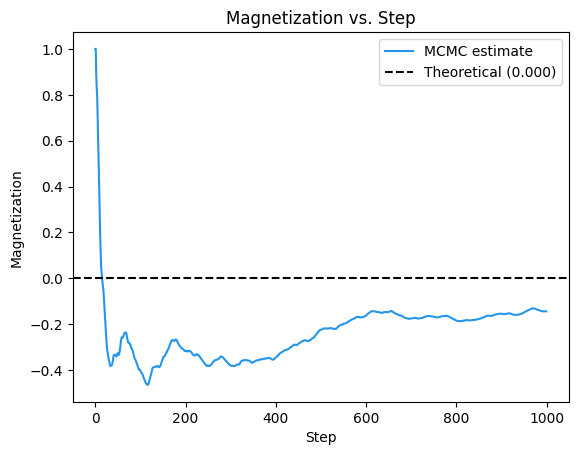

In [7]:
def average_magnetization(sample: np.ndarray) -> float:
    """Return the average magnetization estimated from MCMC samples of shape
    ``(T, n_spins)``."""
    magnetization = np.mean(sample, axis=1)
    return np.mean(magnetization)


sample_magnetization = np.array(
    [average_magnetization(sample[:i]) for i in range(1, T + 1)]
)

# Compute the theoretical average magnetization from the Boltzmann distribution
# at the current inverse temperature beta
weights = np.exp(-beta * energies)
probs = weights / weights.sum()
magnetization_per_state = all_states.mean(axis=1)
theoretical_magnetization = np.sum(probs * magnetization_per_state)
# Z2 symmetry: flipping every spin leaves the (h_i = 0) energy invariant
# while negating the magnetization, so the Boltzmann-weighted mean is zero
# exactly — and the per-state contributions cancel exactly in floating
# point because the {+spins, -spins} pairs share the same `probs` value.
assert theoretical_magnetization == 0.0
assert np.isclose(probs.sum(), 1.0)

plt.plot(sample_magnetization, color=QAOA_BLUE, label="MCMC estimate")
plt.axhline(
    theoretical_magnetization,
    color="black",
    linestyle="--",
    label=f"Theoretical ({theoretical_magnetization:.3f})",
)
plt.xlabel("Step")
plt.ylabel("Magnetization")
plt.title("Magnetization vs. Step")
plt.legend()
plt.show()

---
## Algorithm

The Quantum-enhanced MCMC algorithm is an MCMC that uses sampling from a
quantum circuit as its proposal distribution
{cite:p}`10.1038/s41586-023-06095-4`.
Starting from the current state $\bm{x}$, we apply a quantum circuit $U$
and measure in the computational basis to obtain a new state $\bm{y}$.
The resulting proposal distribution $Q(\bm{y}|\bm{x})$ is:
$$
Q(\bm{y}|\bm{x}) = \| \langle \bm{y} | U | \bm{x} \rangle \|^2
$$
Computing this probability directly is difficult, but when the quantum
circuit satisfies $U = U^\top$, the proposal distribution satisfies
$Q(\bm{x} \mid \bm{y}) = Q(\bm{y} \mid \bm{x})$, so the $Q$ terms cancel
out in the acceptance probability, eliminating the need to explicitly
compute $Q$.
For example, to sample from the Boltzmann distribution of the Ising model,
we can use a trotterized time evolution under a time-independent Hamiltonian:
$$
U(\gamma, t) = \exp(-i H t), \quad \quad
H = (1-\gamma) \alpha H_C + \gamma H_M.
$$
Here, $H_M$ is called the mixer Hamiltonian and generates quantum
transitions between states, while $H_C$ is the Ising Hamiltonian.
$\gamma \in [0,1]$ controls the weight of the mixer Hamiltonian.
The normalization factor
$\alpha = \lVert H_M \rVert_F / \lVert H_C \rVert_F$ places the mixer and
cost Hamiltonians on the same Frobenius-norm scale.
$(\gamma, t)$ are tunable parameters that determine the efficiency of the
MCMC process.

---
## Implementation with Qamomile

### 1. Preparing the Hamiltonians
Now let us implement the algorithm.
First, we prepare the Ising Hamiltonian $H_C$ for the model we wish to
sample and the mixer Hamiltonian $H_M$ for the proposal circuit $U$.

In [8]:
mixer_hamiltonian = Hamiltonian()
for i in range(n_spins):
    mixer_hamiltonian += X(i)

cost_hamiltonian = Hamiltonian()
for i in range(n_spins - 1):
    cost_hamiltonian += -J * Z(i) * Z(i + 1)

# The common 2**(n_spins / 2) factor in both Frobenius norms cancels.
alpha = np.sqrt(
    sum(abs(coefficient) ** 2 for coefficient in mixer_hamiltonian.terms.values())
    / sum(abs(coefficient) ** 2 for coefficient in cost_hamiltonian.terms.values())
)
assert np.isclose(alpha, np.sqrt(n_spins / ((n_spins - 1) * J**2)))

### 2. Building the Quantum Circuit

Next, let us implement the quantum circuit.
First, we prepare the quantum state $\ket{\bm{x}}$ using
`computational_basis_state` in order to encode the current state $\bm{x}$
as the input state.
The proposal transition uses time evolution simulation based on Trotter
decomposition.
We use `trotterized_time_evolution` to build the circuit for the
Hamiltonians we just prepared.

In [9]:
@qmc.qkernel
def qemcmc_circuit(
    n: qmc.UInt,
    input_bits: qmc.Vector[qmc.UInt],
    Hs: qmc.Vector[qmc.Observable],
    order: qmc.UInt,
    time: qmc.Float,
    step: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    """QeMCMC proposal circuit: prepare ``|input_bits>`` on ``n`` qubits,
    evolve under ``sum_k Hs[k]`` using a Suzuki-Trotter splitting of given
    ``order`` and ``step`` steps over total time ``time``, then measure all
    qubits."""
    q = qmc.qubit_array(n, name="q")

    # step 1: prepare the initial state
    q = computational_basis_state(q, input_bits)

    # step 2: apply the trotterized evolution under the mixer and cost Hamiltonians
    q = trotterized_time_evolution(q, Hs, order, time, step)

    return qmc.measure(q)

### 3. Transpiling

We transpile the kernel.
Running the quantum circuit requires fixed values for the Hamiltonian
mixer weight $\gamma$ and the simulation time $t$.
Following {cite:t}`10.1103/PhysRevA.111.042615`, we set
$\gamma=0.45$, $t=12$, and $\Delta t = 0.8$.
At transpile time we bind `n`, `order`, `time`, and `step`, while keeping `input_bits`
as a runtime parameter.

In [10]:
gamma = 0.45  # Mixer weight
time = 12.0  # Total evolution time
delta_t = 0.8  # Trotter step size
step = int(time / delta_t)  # Number of Trotter steps
order = 2  # Suzuki-Trotter approximation order
assert step == 15  # 12.0 / 0.8

Hs = [
    gamma * mixer_hamiltonian,
    (1 - gamma) * alpha * cost_hamiltonian,
]
assert len(Hs) == 2

transpiler = QiskitTranspiler()

executable = transpiler.transpile(
    qemcmc_circuit,
    bindings={
        "n": n_spins,
        "Hs": Hs,
        "order": order,
        "time": time,
        "step": step,
    },
    parameters=["input_bits"],
)

The diagram below shows the Qamomile-level proposal circuit for a
representative alternating input state. Loops are folded to keep the
repeated Suzuki-Trotter structure compact.

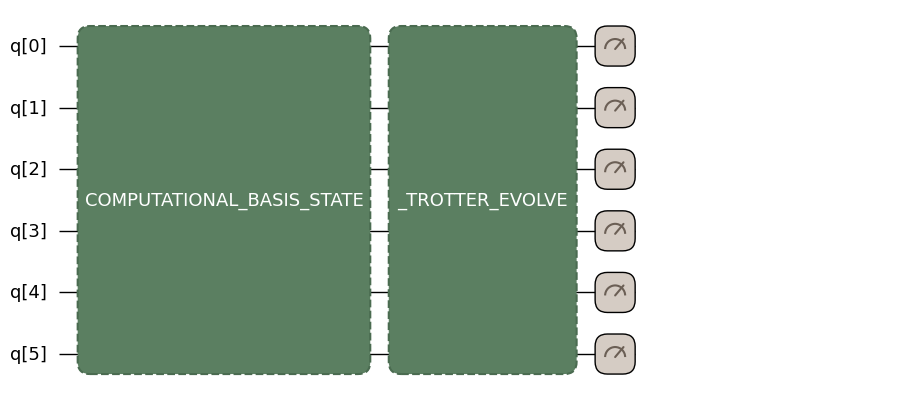

In [11]:
qemcmc_circuit.draw(
    n=n_spins,
    input_bits=[i % 2 for i in range(n_spins)],
    Hs=Hs,
    order=order,
    time=time,
    step=step,
)

### 4. Incorporating the Quantum Circuit into MCMC

The quantum circuit simulation is now ready.
Finally, let us plug the quantum component into the MCMC.
Since the circuit's input and output are bit strings
$\bm{x} \in \{0,1\}^n$, we also prepare a conversion between bit strings
and spin variables $\bm{s} \in \{1, -1\}^n$.

In [12]:
def spin_binary_convert(x: np.ndarray, *, input_kind: str = "auto") -> np.ndarray:
    """Convert between spin variables {-1, +1} and binary variables {0, 1}.

    ``input_kind`` selects the input convention: ``"spin"`` treats ``x`` as
    {-1, +1} and returns binary, ``"binary"`` treats ``x`` as {0, 1} and
    returns spin. The default ``"auto"`` infers the convention from the
    values, but raises ``ValueError`` for the ambiguous all-ones input.
    """
    x = np.asarray(x, dtype=int)
    values = np.unique(x)

    if input_kind == "spin":
        if not np.all(np.isin(values, [-1, 1])):
            raise ValueError(
                f"input_kind='spin' requires elements in {{-1, 1}}, "
                f"got: {values.tolist()}"
            )
        return (1 - x) // 2
    if input_kind == "binary":
        if not np.all(np.isin(values, [0, 1])):
            raise ValueError(
                f"input_kind='binary' requires elements in {{0, 1}}, "
                f"got: {values.tolist()}"
            )
        return 1 - 2 * x
    if input_kind != "auto":
        raise ValueError(
            f"input_kind must be 'spin', 'binary', or 'auto', got: {input_kind!r}"
        )

    if np.any(values == -1) and np.all(np.isin(values, [-1, 1])):
        return (1 - x) // 2
    if np.any(values == 0) and np.all(np.isin(values, [0, 1])):
        return 1 - 2 * x
    if np.array_equal(values, [1]):
        raise ValueError(
            "Cannot infer spin/binary representation when the input is all ones; "
            "pass input_kind='spin' or input_kind='binary' explicitly."
        )
    raise ValueError(
        f"Elements must be drawn from {{-1, 1}} or {{0, 1}}, got: {values.tolist()}"
    )


def quantum_proposal(state: np.ndarray, executable: Any, executor: Any) -> np.ndarray:
    """Obtain a proposed state from the quantum circuit using the current
    spin state as input."""
    binary_state = spin_binary_convert(state, input_kind="spin").tolist()
    result = executable.sample(
        executor,
        shots=1,
        bindings={"input_bits": binary_state},
    ).result()
    ((proposed_bits, _count),) = result.results
    return spin_binary_convert(np.array(proposed_bits, dtype=int), input_kind="binary")

---
## Result

Let us run the QeMCMC algorithm we just implemented.
We switch to a lower temperature $\beta = 2.0$ where classical local
updates mix slowly, so that we can observe the behavior of the quantum
proposal distribution under conditions that are harder for the classical
baseline. For a fair comparison, we also run a classical MCMC at the same
$\beta = 2.0$ alongside the quantum run.

In [13]:
beta = 2.0  # Switch to a lower temperature where local updates mix slowly
T_quantum = (
    20 if docs_test_mode else 1000
)  # Kept small because quantum-circuit simulation is costly

# Generate a reproducible sequence of distinct seeds without resetting every
# sampling job to the same pseudorandom stream.
quantum_job_seeds = np.random.default_rng(seed=RANDOM_SEED).integers(
    0,
    np.iinfo(np.uint32).max,
    size=T_quantum,
    dtype=np.uint32,
)
assert np.unique(quantum_job_seeds).size == T_quantum

# Recompute the theoretical average magnetization for the new beta=2.0
weights = np.exp(-beta * energies)
probs = weights / weights.sum()
theoretical_magnetization = np.sum(probs * magnetization_per_state)
# Still zero by Z2 symmetry: beta only reweights pairs, it does not break
# the {+spins, -spins} degeneracy.
assert theoretical_magnetization == 0.0

# Run a classical MCMC at the same beta and step count for a fair comparison
classical_compare_sample = np.zeros((T_quantum, n_spins))
state = np.ones(n_spins)  # Initial state
for t in range(T_quantum):
    new_state = local_update(state)
    state = metropolis_hastings(state, new_state, ising_energy, beta)
    classical_compare_sample[t] = state

# QeMCMC
quantum_backend = AerSimulator()
executor = transpiler.executor(backend=quantum_backend)
quantum_sample = np.zeros((T_quantum, n_spins), dtype=int)
state = np.ones(n_spins, dtype=int)  # Initial state
for t, job_seed in enumerate(quantum_job_seeds):
    quantum_backend.set_options(seed_simulator=int(job_seed))
    proposed_state = quantum_proposal(state, executable, executor)
    state = metropolis_hastings(state, proposed_state, ising_energy, beta)
    quantum_sample[t] = state
# Both chains produced exactly T_quantum samples on n_spins sites with
# spin values restricted to +/- 1.
assert quantum_sample.shape == (T_quantum, n_spins)
assert classical_compare_sample.shape == (T_quantum, n_spins)
assert set(np.unique(quantum_sample).tolist()).issubset({-1, 1})

We compute the estimator of the average magnetization and compare it with
the classical MCMC result obtained at the same $\beta = 2.0$.

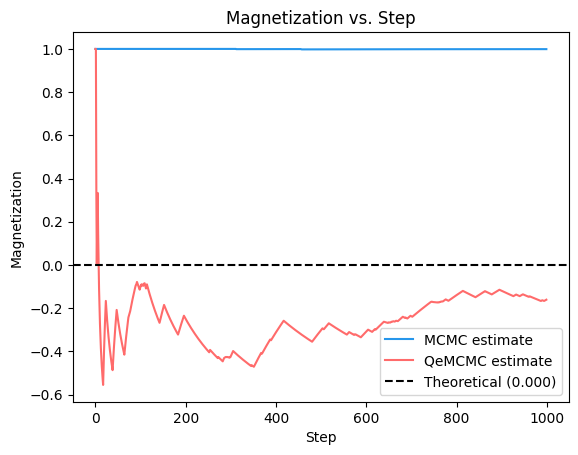

In [14]:
quantum_sample_magnetization = np.array(
    [average_magnetization(quantum_sample[:i]) for i in range(1, T_quantum + 1)]
)
classical_compare_magnetization = np.array(
    [
        average_magnetization(classical_compare_sample[:i])
        for i in range(1, T_quantum + 1)
    ]
)

plt.plot(classical_compare_magnetization, color=QAOA_BLUE, label="MCMC estimate")
plt.plot(quantum_sample_magnetization, color=QAOA_RED, label="QeMCMC estimate")
plt.axhline(
    theoretical_magnetization,
    color="black",
    linestyle="--",
    label=f"Theoretical ({theoretical_magnetization:.3f})",
)
plt.xlabel("Step")
plt.ylabel("Magnetization")
plt.title("Magnetization vs. Step")
plt.legend()
plt.show()

At low temperatures, local updates are less likely to transition to a
different configuration, making mixing extremely slow. In contrast, QeMCMC
uses transitions generated by the quantum circuit, allowing the state to
change frequently even at low temperatures and the estimate to converge
toward the exact value.

---
## Summary

In this notebook, we:

- Reviewed how classical Metropolis-Hastings MCMC samples a Boltzmann
  distribution and why local updates mix slowly at low temperatures.
- Implemented time evolution under mixer and cost Hamiltonians with
  `trotterized_time_evolution` and built a QeMCMC proposal circuit in
  Qamomile.
- Integrated quantum proposals into the Metropolis-Hastings procedure and
  compared QeMCMC with classical MCMC.